<div align="center">

# Regresion Lineal 2

### 30 Septiembre de 2026

<br>

<img src="img/logoitqv1.jpg" width="650">

<br><br>

</div>

# Regresion Lineal 2

<div align="center">

<img src="img/python_logo.png" width="550">

</div>

<div align="left">

### Eric Campoverde

<a href="https://github.com/EricJordy/MachineLearning2.git">Repositorio Git</a>

</div>

<hr style="height:3px;border:none;background:#b30000;">


# 1. Importación de librerías

En esta sección se importan las librerías necesarias para desarrollar el modelo de regresión lineal. Estas bibliotecas permiten realizar operaciones matemáticas, cargar conjuntos de datos, entrenar el modelo, evaluar su rendimiento y visualizar los resultados obtenidos.

In [1]:
# IMPORTACIÓN DE LIBRERÍAS

# NumPy permite trabajar con arreglos y realizar operaciones
# matemáticas de forma eficiente.
import numpy as np

# Se importa la función sqrt para calcular la raíz cuadrada.
from math import sqrt

# pprint permite imprimir estructuras de datos de manera
# organizada y fácil de leer.
from pprint import pprint

# Se importan los módulos necesarios de Scikit-Learn para
# cargar datos, construir modelos de regresión y evaluar
# su desempeño.
from sklearn import datasets, linear_model, metrics

# Modelo de referencia (baseline) utilizado para comparar
# el rendimiento del modelo de regresión.
from sklearn.dummy import DummyRegressor

# Herramientas para dividir los datos y realizar
# validación cruzada.
from sklearn.model_selection import (
    cross_validate, KFold, cross_val_predict, train_test_split, cross_val_score)

# Librería utilizada para estandarizar las variables
# antes del entrenamiento del modelo.
from sklearn import preprocessing

# Funciones para crear métricas personalizadas
# y calcular el error cuadrático medio.
from sklearn.metrics import make_scorer, mean_squared_error

# Matplotlib permite generar gráficos para visualizar
# los resultados del modelo.
import matplotlib.pyplot as plt

# 2. Carga del conjunto de datos

In [10]:
# CARGA DEL CONJUNTO DE DATOS

# Se carga el conjunto de datos California Housing.
datos = datasets.fetch_california_housing()

# Variables independientes (características).
X = datos.data

# Variable objetivo.
y = datos.target

# Se muestran las dimensiones del conjunto de datos.
print("Dimensiones de X:", np.shape(X))

Dimensiones de X: (20640, 8)


# 3. Definición de métricas de evaluación

- **MAE:** Error Absoluto Medio.
- **RMSE:** Raíz del Error Cuadrático Medio.
- **MAPE:** Error Porcentual Absoluto Medio.
- **R²:** Coeficiente de Determinación.

In [11]:
# MÉTRICAS DE EVALUACIÓN

# Se define un diccionario con las métricas que serán utilizadas para evaluar el modelo durante la validación cruzada.
metricas = {

    # Error Absoluto Medio (Mean Absolute Error)
    'MAE': 'neg_mean_absolute_error',

    # Raíz del Error Cuadrático Medio (Root Mean Squared Error)
    'RMSE': make_scorer(
        lambda y, y_pred: sqrt(metrics.mean_squared_error(y, y_pred)),
        greater_is_better=False
    ),

    # Error Porcentual Absoluto Medio
    'MAPE': make_scorer(
        lambda y, y_pred: np.mean(np.abs((y - y_pred) / y)) * 100,
        greater_is_better=False
    ),

    # Coeficiente de Determinación
    'R2': 'r2'
}

# 4. Partición del conjunto de datos

- Datos de entrenamiento (80%)
- Datos de prueba (20%)

In [12]:
# 
# PARTICIÓN DEL CONJUNTO DE DATOS
# 

# Se divide el conjunto de datos en entrenamiento (80%)
# y prueba (20%).
X_training, X_testing, y_training, y_testing = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Se muestra el tamaño del conjunto de entrenamiento.
print("Dimensiones de X_training:", np.shape(X_training))

Dimensiones de X_training: (16512, 8)


# 5. Estandarización de los datos

Antes de entrenar el modelo es recomendable estandarizar las variables de entrada para que todas tengan una escala similar.

La estandarización transforma cada característica para que tenga una media cercana a cero y una desviación estándar igual a uno, mejorando la estabilidad del entrenamiento.

In [13]:
# ESTANDARIZACIÓN DE LOS DATOS

# Se crea el objeto encargado de estandarizar los datos
standardizer = preprocessing.StandardScaler()

# Se calculan la media y desviación estándar utilizando únicamente los datos de entrenamiento
stdr_trained = standardizer.fit(X_training)

# Se transforman los datos de entrenamiento
X_stdr = stdr_trained.transform(X_training)

# 6. Construcción del modelo de regresión lineal

In [14]:
# CONSTRUCCIÓN DEL MODELO

# Se crea el modelo de Regresión Lineal, fit_intercept=True permite calcular el intercepto de la recta de regresión
reg = linear_model.LinearRegression(fit_intercept=True)

# 7. Validación cruzada

In [15]:
# VALIDACIÓN CRUZADA

# Se evalúa el modelo mediante validación cruzada utilizando cinco particiones 

cross_val_results = cross_validate(
    reg,
    X_stdr,
    y_training,
    cv=KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),
    scoring=metricas
)

# Se muestran todas las métricas obtenidas durante la validación cruzada.
pprint(cross_val_results)

{'fit_time': array([0.27355194, 0.00734472, 0.00767231, 0.00694132, 0.00732565]),
 'score_time': array([0.00569224, 0.00475454, 0.00456834, 0.00459313, 0.00463867]),
 'test_MAE': array([-0.54071407, -0.52878981, -0.51274193, -0.53512422, -0.52793364]),
 'test_MAPE': array([-31.74769388, -31.65516613, -30.97054077, -32.61432353,
       -30.685065  ]),
 'test_R2': array([0.60970239, 0.60411343, 0.6354319 , 0.60076148, 0.60727452]),
 'test_RMSE': array([-0.73389779, -0.72516701, -0.69726867, -0.73337185, -0.71284225])}


# 8. Entrenamiento del modelo

In [16]:
# ENTRENAMIENTO DEL MODELO

# Se entrena el modelo utilizando todos los datos de entrenamiento previamente estandarizados
model = reg.fit(X_stdr, y_training)

# Se obtienen los coeficientes del modelo
w = model.coef_

print("Coeficientes del modelo:\n")
print(w)

# Se obtiene el término independiente (intercepto).
w_0 = model.intercept_

print("\nTérmino independiente:")
print(w_0)

Coeficientes del modelo:

[ 0.85438303  0.12254624 -0.29441013  0.33925949 -0.00230772 -0.0408291
 -0.89692888 -0.86984178]

Término independiente:
2.071946937378619


# 9. Preparación del conjunto de prueba

In [17]:
# PREPARACIÓN DEL CONJUNTO DE PRUEBA

# Se estandarizan los datos del conjunto de prueba utilizando el mismo escalador entrenado con los datos de entrenamiento
# Esto garantiza que ambos conjuntos tengan la misma escala
X_test_stdr = stdr_trained.transform(X_testing)

# 10. Predicción del modelo

In [18]:
# PREDICCIÓN DEL CONJUNTO DE PRUEBA

# El modelo realiza la predicción sobre los datos de prueba.
y_pred_test = model.predict(X_test_stdr)

# 11. Evaluación del modelo

In [19]:
# CÁLCULO DE LAS MÉTRICAS DE EVALUACIÓN

# Se calcula el Error Absoluto Medio.
MAE = metrics.mean_absolute_error(y_testing, y_pred_test)

# Se calcula el Error Cuadrático Medio.
MSE = metrics.mean_squared_error(y_testing, y_pred_test)

# Se calcula la Raíz del Error Cuadrático Medio.
RMSE = np.sqrt(MSE)

# Se calcula el Error Porcentual Absoluto Medio.
MAPE = metrics.mean_absolute_percentage_error(y_testing, y_pred_test)

# Se calcula el Coeficiente de Determinación.
R2 = metrics.r2_score(y_testing, y_pred_test)

# Se muestran los resultados obtenidos.
print(f"MAE  : {MAE:.4f}")
print(f"MSE  : {MSE:.4f}")
print(f"RMSE : {RMSE:.4f}")
print(f"MAPE : {MAPE:.4f}")
print(f"R²   : {R2:.4f}")

MAE  : 0.5332
MSE  : 0.5559
RMSE : 0.7456
MAPE : 0.3195
R²   : 0.5758


# 12. Visualización de resultados

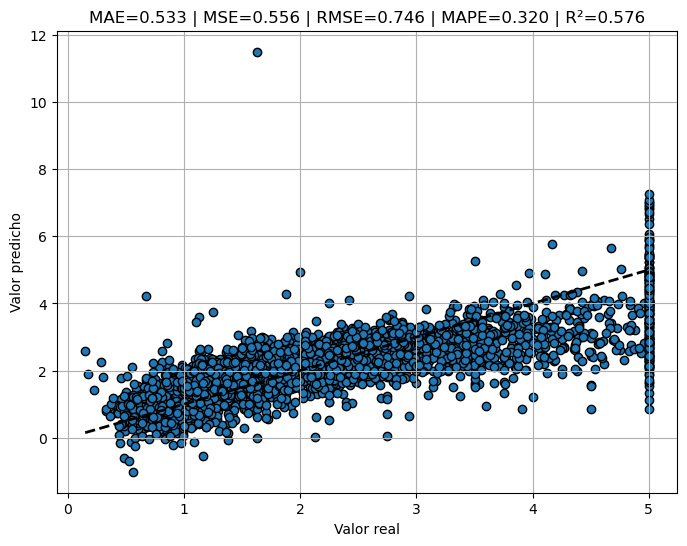

In [20]:
# GRÁFICA DE VALORES REALES VS PREDICCIONES

# Se crea la figura donde se compararán los valores reales con los valores predichos.
fig, ax = plt.subplots(figsize=(8, 6))

# Se dibuja el diagrama de dispersión.
ax.scatter(
    y_testing,
    y_pred_test,
    edgecolors="black"
)

# Se dibuja la línea de referencia ideal.
ax.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    "k--",
    lw=2
)

# Etiquetas de los ejes.
ax.set_xlabel("Valor real")
ax.set_ylabel("Valor predicho")

# Título con las métricas obtenidas.
plt.title(
    f"MAE={MAE:.3f} | "
    f"MSE={MSE:.3f} | "
    f"RMSE={RMSE:.3f} | "
    f"MAPE={MAPE:.3f} | "
    f"R²={R2:.3f}"
)

# Se activa la cuadrícula para facilitar la lectura.
plt.grid(True)

# Se muestra la gráfica.
plt.show()